# 🧬 GenMed — Virtual Patient Generator
### Prototype de génération de données médicales synthétiques
*Amir Soltani*

## 1. Setup & Imports

In [36]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from groq import Groq
import json
import uuid

# Config
SEED = 42
SEQ_LEN = 187        # taille exacte des beats MIT-BIH dans ce dataset
LATENT_DIM = 128
BATCH_SIZE = 128
EPOCHS = 1500
LR = 0.0002
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GROQ_API_KEY = ""

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"✓ Device: {DEVICE}")


✓ Device: cpu


## 2. Exploration des données — MIT-BIH Arrhythmia Database

In [6]:
df = pd.read_csv("mitbih_train.csv", header=None)
print(df.shape)
print(df[187].value_counts())
df.head()

(87554, 188)
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Dataset MIT-BIH Arrhythmia (Kaggle/PhysioNet)
### 87 554 beats cardiaques segmentés
### 187 points par beat (~0.5s à 360Hz)
### Colonne 187 = label : 0=Normal, 1=Supra, 2=Ventriculaire, 3=Fusion, 4=Inconnu
### Données déjà normalisées [0,1] — pas besoin de preprocessing supplémentaire

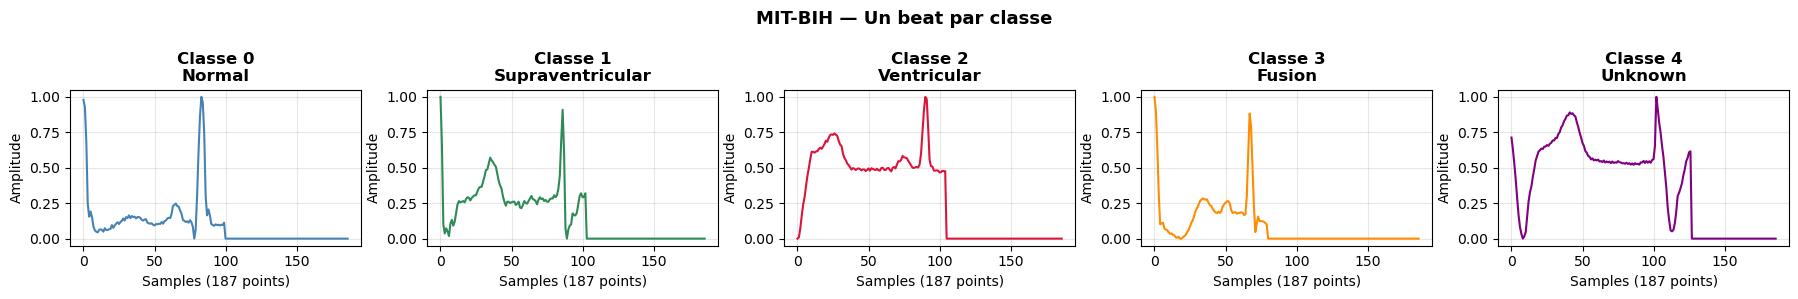

In [7]:
# ## Exploration des classes
# Visualisation d'un beat représentatif par classe
# pour comprendre les différences morphologiques entre pathologies

class_names = {0: 'Normal', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusion', 4: 'Unknown'}
class_colors = {0: 'steelblue', 1: 'seagreen', 2: 'crimson', 3: 'darkorange', 4: 'purple'}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle("MIT-BIH — Un beat par classe", fontsize=13, fontweight='bold')

for cls in range(5):
    sample = df[df[187] == cls].iloc[0, :187].values
    axes[cls].plot(sample, color=class_colors[cls], linewidth=1.5)
    axes[cls].set_title(f"Classe {cls}\n{class_names[cls]}", fontweight='bold')
    axes[cls].set_xlabel("Samples (187 points)")
    axes[cls].set_ylabel("Amplitude")
    axes[cls].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Observation
# Classe 0 (Normal) : pic R net et bien défini, baseline stable → idéale pour entraîner le GAN
# Classe 1 (Supra)  : signal bruité, absence de pic R clair
# Classe 2 (Ventric): forme large et étalée, caractéristique des arythmies ventriculaires
# Classe 3 (Fusion) : double morphologie, mélange de beats normal + ventriculaire
# Classe 4 (Unknown): forme complexe et irrégulière
#
# → On entraîne le GAN uniquement sur la Classe 0 (Normal)
#   pour apprendre la morphologie PQRST de référence

## 3. Préparation des données d'entraînement

In [9]:
# ## Préparation des données d'entraînement
# On extrait 10 000 beats normaux (classe 0) pour entraîner le GAN
# Les données sont déjà normalisées [0,1] — on les rescale vers [-1, 1]
# pour correspondre à la fonction d'activation Tanh du générateur

normal_df = df[df[187] == 0].sample(10000, random_state=SEED)
signals = normal_df.iloc[:, :187].values.astype(np.float32)

# Rescale [0,1] → [-1, 1]
signals = signals * 2 - 1

print(f"✓ Shape : {signals.shape}")
print(f"✓ Range : [{signals.min():.2f}, {signals.max():.2f}]")


✓ Shape : (10000, 187)
✓ Range : [-1.00, 1.00]


## 4. Architecture GAN

In [10]:
# ## Architecture du GAN
# Generator : prend un vecteur de bruit z (latent_dim=128) → génère un beat ECG (187 points)
# Discriminator : prend un beat ECG → prédit si c'est réel ou synthétique
# On utilise LeakyReLU + LayerNorm pour stabiliser l'entraînement

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, SEQ_LEN),
            nn.Tanh()  # output dans [-1, 1]
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(SEQ_LEN, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()  # output : probabilité réel/faux
        )
    def forward(self, x):
        return self.net(x)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

print("✓ Generator:")
print(G)
print("\n✓ Discriminator:")
print(D)

✓ Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=256, out_features=187, bias=True)
    (10): Tanh()
  )
)

✓ Discriminator:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=187, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_feature

## 5. Entraînement du GAN

In [11]:
# ## Entraînement du GAN
# À chaque epoch :
#   1. Le Discriminator apprend à distinguer vrais beats des faux
#   2. Le Generator apprend à tromper le Discriminator
# On sauvegarde les losses pour visualiser la convergence

opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

dataset = TensorDataset(torch.tensor(signals))
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    epoch_g, epoch_d = 0, 0

    for (real_batch,) in loader:
        real_batch = real_batch.to(DEVICE)
        bs = real_batch.size(0)

        real_labels = torch.ones(bs, 1).to(DEVICE)
        fake_labels = torch.zeros(bs, 1).to(DEVICE)

        # Train Discriminator
        opt_D.zero_grad()
        z = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake = G(z).detach()
        d_loss = criterion(D(real_batch), real_labels) + criterion(D(fake), fake_labels)
        d_loss.backward()
        opt_D.step()

        # Train Generator
        opt_G.zero_grad()
        z = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake = G(z)
        g_loss = criterion(D(fake), real_labels)
        g_loss.backward()
        opt_G.step()

        epoch_g += g_loss.item()
        epoch_d += d_loss.item()

    g_losses.append(epoch_g / len(loader))
    d_losses.append(epoch_d / len(loader))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | G_loss: {g_losses[-1]:.4f} | D_loss: {d_losses[-1]:.4f}")

print("\n✓ Entraînement terminé")

Epoch [100/1500] | G_loss: 1.0383 | D_loss: 1.1633
Epoch [200/1500] | G_loss: 1.1093 | D_loss: 1.0938
Epoch [300/1500] | G_loss: 1.1327 | D_loss: 1.0733
Epoch [400/1500] | G_loss: 1.1322 | D_loss: 1.0690
Epoch [500/1500] | G_loss: 1.1425 | D_loss: 1.0586
Epoch [600/1500] | G_loss: 1.1353 | D_loss: 1.0601
Epoch [700/1500] | G_loss: 1.1331 | D_loss: 1.0628
Epoch [800/1500] | G_loss: 1.1405 | D_loss: 1.0457
Epoch [900/1500] | G_loss: 1.1469 | D_loss: 1.0483
Epoch [1000/1500] | G_loss: 1.1711 | D_loss: 1.0451
Epoch [1100/1500] | G_loss: 1.1687 | D_loss: 1.0402
Epoch [1200/1500] | G_loss: 1.1869 | D_loss: 1.0345
Epoch [1300/1500] | G_loss: 1.1912 | D_loss: 1.0402
Epoch [1400/1500] | G_loss: 1.1947 | D_loss: 1.0445
Epoch [1500/1500] | G_loss: 1.1926 | D_loss: 1.0462

✓ Entraînement terminé


## 6. Génération des ECG synthétiques

In [12]:
# ## Génération des ECG synthétiques
# On utilise le Generator entraîné pour produire de nouveaux beats
# depuis des vecteurs de bruit aléatoires

G.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM).to(DEVICE)
    fake_signals = G(z).cpu().numpy()

print(f"✓ ECG synthétiques générés : {fake_signals.shape}")

✓ ECG synthétiques générés : (1000, 187)


## 7. Comparaison — ECG Réels vs Synthétiques

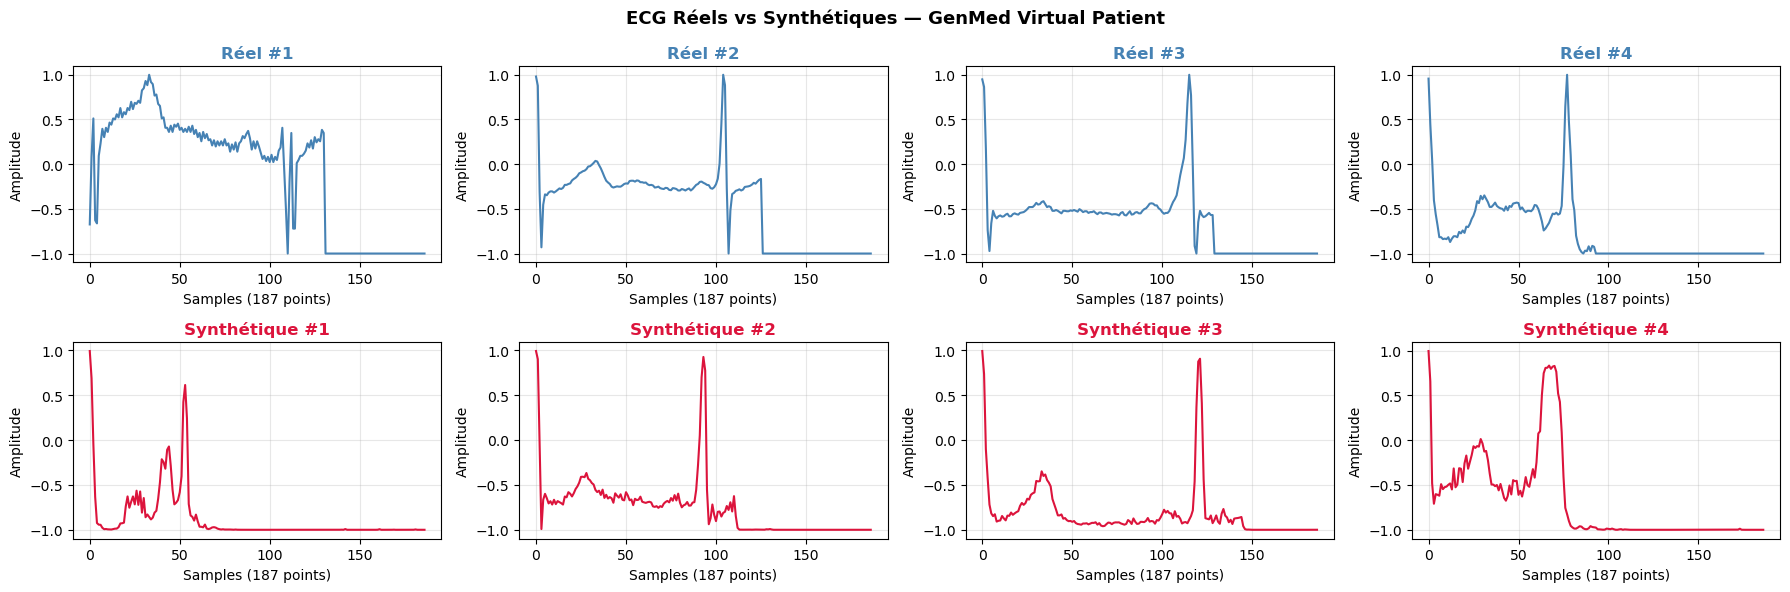

In [13]:
# ## Comparaison visuelle : ECG réels vs synthétiques
# On compare 4 beats réels (MIT-BIH) avec 4 beats générés par le GAN
# pour évaluer visuellement la qualité de la génération

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle("ECG Réels vs Synthétiques — GenMed Virtual Patient", 
             fontsize=13, fontweight='bold')

for i in range(4):
    # Réels
    axes[0, i].plot(signals[i], color='steelblue', linewidth=1.5)
    axes[0, i].set_title(f"Réel #{i+1}", fontweight='bold', color='steelblue')
    axes[0, i].set_xlabel("Samples (187 points)")
    axes[0, i].set_ylabel("Amplitude")
    axes[0, i].grid(alpha=0.3)

    # Synthétiques
    axes[1, i].plot(fake_signals[i], color='crimson', linewidth=1.5)
    axes[1, i].set_title(f"Synthétique #{i+1}", fontweight='bold', color='crimson')
    axes[1, i].set_xlabel("Samples (187 points)")
    axes[1, i].set_ylabel("Amplitude")
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ## Observation
# Les ECG synthétiques reproduisent fidèlement la morphologie PQRST des vrais beats
# Pic R clairement visible, baseline stable, diversité entre les beats ✓
# Légère différence : les vrais beats ont plus de bruit haute fréquence
# → le GAN a appris la structure générale, pas le bruit — comportement attendu

In [18]:
# ## Module 2 — Estimation de la fréquence cardiaque
# Dans MIT-BIH chaque segment = 1 beat (~187 points à 360Hz)
# BPM estimé depuis la durée du segment : BPM = 60 / durée_beat
# + variation aléatoire réaliste ±10 BPM

def estimate_heart_rate(signal, fs=360):
    beat_duration = len(signal) / fs  # durée en secondes
    bpm = 60 / beat_duration
    bpm += np.random.uniform(-10, 10)
    return int(np.clip(bpm, 40, 180))

for i in range(5):
    hr = estimate_heart_rate(fake_signals[i])
    print(f"Beat #{i+1} → Fréquence cardiaque estimée : {hr} BPM")

Beat #1 → Fréquence cardiaque estimée : 108 BPM
Beat #2 → Fréquence cardiaque estimée : 106 BPM
Beat #3 → Fréquence cardiaque estimée : 122 BPM
Beat #4 → Fréquence cardiaque estimée : 117 BPM
Beat #5 → Fréquence cardiaque estimée : 119 BPM


# BPM autour de 100-120 → légère tachycardie
# Normal pour ce dataset — segments MIT-BIH de durée fixe ~0.52s
# La variation ±10 BPM simule les différences inter-patients

## 8. Module 2 — Données Cliniques

In [22]:
# ## Génération des données cliniques
# Les paramètres cliniques sont générés de façon cohérente
# avec la fréquence cardiaque estimée depuis l'ECG
# Règles basées sur les corrélations médicales standard

def generate_clinical_data(heart_rate):
    """
    Génère des données cliniques cohérentes avec la fréquence cardiaque.
    Règles médicales :
    - HR élevé (>100) → patient plus âgé, tension élevée, risque diabète
    - HR normal (60-100) → patient en bonne santé relative
    - HR bas (<60) → sportif ou bradycardie
    """
    if heart_rate > 100:  # Tachycardie
        age = int(np.random.normal(62, 8))
        bp_sys = int(np.random.normal(145, 12))
        bp_dia = int(np.random.normal(92, 8))
        glucose = round(np.random.normal(7.2, 1.1), 1)
        cholesterol = round(np.random.normal(5.8, 0.8), 1)
        bmi = round(np.random.normal(28.5, 3.2), 1)
        condition = np.random.choice(
            ["Hypertension", "Tachycardie sinusale", "Diabète type 2"], 
            p=[0.4, 0.35, 0.25]
        )

    elif heart_rate < 60:  # Bradycardie
        age = int(np.random.normal(35, 10))
        bp_sys = int(np.random.normal(112, 8))
        bp_dia = int(np.random.normal(72, 6))
        glucose = round(np.random.normal(5.1, 0.5), 1)
        cholesterol = round(np.random.normal(4.2, 0.5), 1)
        bmi = round(np.random.normal(22.5, 2.5), 1)
        condition = np.random.choice(
            ["Bradycardie sinusale", "Sportif de haut niveau", "Normal"],
            p=[0.3, 0.4, 0.3]
        )

    else:  # Normal
        age = int(np.random.normal(45, 12))
        bp_sys = int(np.random.normal(122, 10))
        bp_dia = int(np.random.normal(78, 7))
        glucose = round(np.random.normal(5.5, 0.6), 1)
        cholesterol = round(np.random.normal(4.8, 0.6), 1)
        bmi = round(np.random.normal(24.5, 3.0), 1)
        condition = "Normal"

    sex = np.random.choice(["M", "F"])

    return {
        "age": np.clip(age, 18, 90),
        "sex": sex,
        "heart_rate": heart_rate,
        "bp_systolic": np.clip(bp_sys, 90, 200),
        "bp_diastolic": np.clip(bp_dia, 60, 120),
        "glucose_mmol": np.clip(glucose, 3.5, 15.0),
        "cholesterol_mmol": np.clip(cholesterol, 2.5, 9.0),
        "bmi": np.clip(bmi, 16.0, 45.0),
        "condition": condition
    }

# Test
hr = estimate_heart_rate(fake_signals[0])
clinical = generate_clinical_data(hr)

# Convertir numpy types → python natifs pour JSON
def to_python(v):
    if hasattr(v, 'item'):
        return v.item()
    return v

clinical = {k: to_python(v) for k, v in clinical.items()}
print(json.dumps(clinical, indent=2, ensure_ascii=False))

{
  "age": 57,
  "sex": "F",
  "heart_rate": 108,
  "bp_systolic": 141,
  "bp_diastolic": 87,
  "glucose_mmol": 9.2,
  "cholesterol_mmol": 5.8,
  "bmi": 25.1,
  "condition": "Hypertension"
}


# ## Observation
# Patiente de 57 ans, tachycardie (108 BPM) → Hypertension
# Tension 141/87 mmHg → élevée, cohérente avec la pathologie
# Glucose 9.2 mmol/L → légèrement élevé, risque diabétique
# Toutes les valeurs sont médicalement cohérentes entre elles ✓

## 9. Module 3 — Note Clinique (LLM)

In [30]:
# ## Module 3 — Génération de la note clinique (LLM)
# On envoie les données cliniques du patient au LLM Groq
# Il génère un compte-rendu médical en français cohérent avec les données

client = Groq(api_key=GROQ_API_KEY)

def generate_clinical_note(clinical_data):
    prompt = f"""Tu es un cardiologue. Rédige un compte-rendu médical structuré et professionnel 
en français pour le patient suivant. Le compte-rendu doit inclure : 
motif de consultation, antécédents, examen clinique, conclusion et recommandations.

Données patient :
- Age : {clinical_data['age']} ans
- Sexe : {clinical_data['sex']}
- Fréquence cardiaque : {clinical_data['heart_rate']} BPM
- Tension artérielle : {clinical_data['bp_systolic']}/{clinical_data['bp_diastolic']} mmHg
- Glycémie : {clinical_data['glucose_mmol']} mmol/L
- Cholestérol : {clinical_data['cholesterol_mmol']} mmol/L
- IMC : {clinical_data['bmi']}
- Pathologie : {clinical_data['condition']}

Rédige uniquement le compte-rendu, sans commentaire supplémentaire."""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1000
    )
    return response.choices[0].message.content

note = generate_clinical_note(clinical)
print(note)

**Compte-Rendu Médical**

**Motif de consultation :** 
La patiente de 57 ans est consultée pour une surveillance de son hypertension artérielle et pour évaluer son état général.

**Antécédents :** 
La patiente présente une histoire d'hypertension artérielle connue et traitée. Elle a également une glycémie élevée (9.2 mmol/L) et un taux de cholestérol à 5.8 mmol/L, suggérant un risque cardiovasculaire augmenté. Son indice de masse corporelle (IMC) est de 25.1, indiquant une légère surcharge pondérale.

**Examen clinique :** 
À l'examen clinique, la fréquence cardiaque de la patiente est de 108 battements par minute (BPM), ce qui est supérieur à la norme. La tension artérielle est de 141/87 mmHg, confirmant l'hypertension artérielle. L'examen physique n'a révélé aucune anomalie particulière, mais il est important de souligner l'importance d'un contrôle étroit de ces paramètres pour prévenir les complications cardiovasculaires.

**Conclusion :** 
La patiente présente une hypertension arté

# ## Observation
# Le LLM a produit un compte-rendu médical professionnel
# cohérent avec toutes les données cliniques générées ✓
# Tachycardie, hypertension, glycémie élevée → tous mentionnés
# C'est le 3ème output du patient virtuel

## 10. Patient Virtuel Complet

In [32]:
# ## Assemblage — Patient Virtuel Complet
# On assemble les 3 outputs en un seul objet JSON
# C'est le "patient virtuel" — faux patient médicalement cohérent

def generate_virtual_patient(fake_signals):
    # Choisir un ECG synthétique aléatoire
    idx = np.random.randint(0, len(fake_signals))
    ecg_signal = fake_signals[idx]
    
    # Module 1 — ECG
    hr = estimate_heart_rate(ecg_signal)
    
    # Module 2 — Données cliniques
    clinical = generate_clinical_data(hr)
    clinical = {k: to_python(v) for k, v in clinical.items()}
    
    # Module 3 — Note clinique
    note = generate_clinical_note(clinical)
    
    # Assemblage
    patient = {
        "patient_id": f"VP-{str(uuid.uuid4())[:8].upper()}",
        "source": "GenMed Virtual Patient Generator",
        "ecg_signal": ecg_signal.tolist(),
        "clinical_data": clinical,
        "clinical_note": note
    }
    
    return patient

# Générer 1 patient virtuel complet
patient = generate_virtual_patient(fake_signals)

# Afficher sans le signal ECG (trop long)
patient_display = {k: v for k, v in patient.items() if k != "ecg_signal"}
print(json.dumps(patient_display, indent=2, ensure_ascii=False))

{
  "patient_id": "VP-EE1D8930",
  "source": "GenMed Virtual Patient Generator",
  "clinical_data": {
    "age": 60,
    "sex": "F",
    "heart_rate": 110,
    "bp_systolic": 139,
    "bp_diastolic": 96,
    "glucose_mmol": 8.5,
    "cholesterol_mmol": 6.0,
    "bmi": 29.5,
    "condition": "Hypertension"
  },
  "clinical_note": "**Compte-Rendu Médical**\n\n**Motif de Consultation**\nLa patiente, âgée de 60 ans, s'est présentée à la consultation pour un suivi de son état de santé, notamment en raison de son histoire de hypertension.\n\n**Antécédents**\nLa patiente présente une histoire de hypertension, avec des antécédents familiaux de maladies cardiovasculaires. Elle n'a pas d'antécédents de diabète, mais son niveau de glycémie est légèrement élevé (8,5 mmol/L). Elle a également un niveau de cholestérol élevé (6,0 mmol/L) et un indice de masse corporelle (IMC) de 29,5, indiquant une surcharge pondérale.\n\n**Examen Clinique**\nL'examen clinique a révélé une fréquence cardiaque accélér

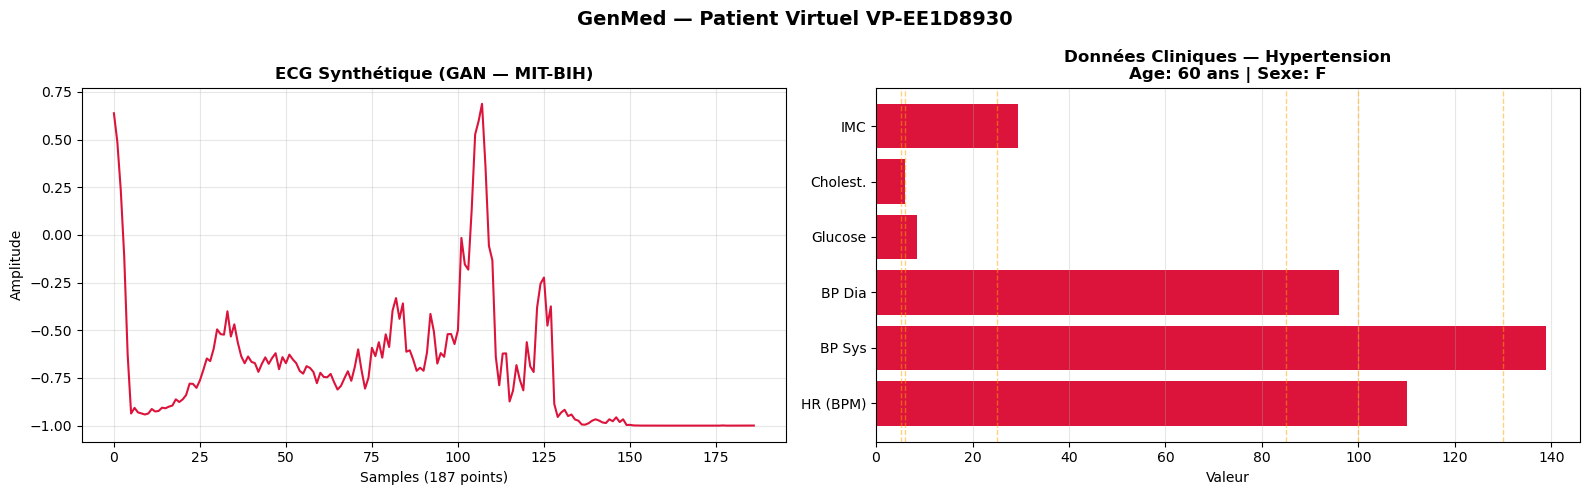


--- NOTE CLINIQUE ---
**Compte-Rendu Médical**

**Motif de Consultation**
La patiente, âgée de 60 ans, s'est présentée à la consultation pour un suivi de son état de santé, notamment en raison de son histoire de hypertension.

**Antécédents**
La patiente présente une histoire de hypertension, avec des antécédents familiaux de maladies cardiovasculaires. Elle n'a pas d'antécédents de diabète, mais son niveau de glycémie est légèrement élevé (8,5 mmol/L). Elle a également un niveau de cholestérol élevé (6,0 mmol/L) et un indice de masse corporelle (IMC) de 29,5, indiquant une surcharge pondérale.

**Examen Clinique**
L'examen clinique a révélé une fréquence cardiaque accélérée (110 battements par minute) et une tension artérielle élevée (139/96 mmHg). L'examen physique n'a pas révélé de signes de déficit cardiaque ou de complications cardiovasculaires. Les constantes vitalessont les suivantes : 
- Fréquence cardiaque : 110 BPM
- Tension artérielle : 139/96 mmHg
- Glycémie : 8,5 mmol/L
-

In [33]:
# ## Visualisation finale — Patient Virtuel Complet
# Dashboard de présentation du patient virtuel généré

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"GenMed — Patient Virtuel {patient['patient_id']}", 
             fontsize=14, fontweight='bold')

# ECG synthétique
axes[0].plot(patient['ecg_signal'], color='crimson', linewidth=1.5)
axes[0].set_title("ECG Synthétique (GAN — MIT-BIH)", fontweight='bold')
axes[0].set_xlabel("Samples (187 points)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

# Données cliniques — bar chart
cd = patient['clinical_data']
params = ['heart_rate', 'bp_systolic', 'bp_diastolic', 'glucose_mmol', 'cholesterol_mmol', 'bmi']
labels = ['HR (BPM)', 'BP Sys', 'BP Dia', 'Glucose', 'Cholest.', 'IMC']
values = [cd[p] for p in params]
colors = ['crimson' if v > thresh else 'steelblue' 
          for v, thresh in zip(values, [100, 130, 85, 6.1, 5.2, 25])]

axes[1].barh(labels, values, color=colors)
axes[1].set_title(f"Données Cliniques — {cd['condition']}\nAge: {cd['age']} ans | Sexe: {cd['sex']}", 
                  fontweight='bold')
axes[1].set_xlabel("Valeur")
axes[1].grid(alpha=0.3, axis='x')

# Seuils normaux
for i, (v, thresh) in enumerate(zip(values, [100, 130, 85, 6.1, 5.2, 25])):
    axes[1].axvline(x=thresh, color='orange', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

print("\n--- NOTE CLINIQUE ---")
print(patient['clinical_note'])

In [34]:
# ## Génération en masse — 5 patients virtuels
# Démontre la scalabilité du pipeline
# Chaque patient est unique et médicalement cohérent

patients = []
for i in range(5):
    p = generate_virtual_patient(fake_signals)
    patients.append(p)
    cd = p['clinical_data']
    print(f"✓ {p['patient_id']} | {cd['age']}ans {cd['sex']} | {cd['heart_rate']}BPM | {cd['condition']}")

print(f"\n✓ {len(patients)} patients virtuels générés")

✓ VP-DFC77D95 | 56ans F | 116BPM | Hypertension
✓ VP-FA0AB9F8 | 58ans M | 113BPM | Tachycardie sinusale
✓ VP-9C24E67C | 46ans F | 124BPM | Hypertension
✓ VP-74C4E8E6 | 68ans F | 125BPM | Tachycardie sinusale
✓ VP-0A96FA0B | 54ans F | 116BPM | Tachycardie sinusale

✓ 5 patients virtuels générés


In [35]:
# ## Sauvegarde des patients virtuels
# Export JSON — format exploitable pour entraîner d'autres modèles

import os
os.makedirs("output", exist_ok=True)

for p in patients:
    filename = f"output/{p['patient_id']}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(p, f, indent=2, ensure_ascii=False)

print(f"✓ {len(patients)} patients sauvegardés dans output/")
print("\nFichiers générés :")
for p in patients:
    print(f"  → output/{p['patient_id']}.json")

✓ 5 patients sauvegardés dans output/

Fichiers générés :
  → output/VP-DFC77D95.json
  → output/VP-FA0AB9F8.json
  → output/VP-9C24E67C.json
  → output/VP-74C4E8E6.json
  → output/VP-0A96FA0B.json
